# Homework 9 — Policy Iteration on FrozenLake

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

FrozenLake is a Markov decision process small enough to solve exactly: 16 states, 4 actions, and a transition model the environment hands over directly. Policy iteration alternates between evaluating the current policy and acting greedily with respect to that evaluation, and provably reaches the optimal policy in a finite number of steps. Both halves are implemented below from the Bellman equations, and the resulting policy is rendered and then tested against the environment.

In [1]:
# Environment setup & imports
try:
    import gymnasium as gym
except ImportError:
    !pip install -q "gymnasium[toy-text]"
    import gymnasium as gym

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})

print(f"gymnasium version: {gym.__version__}")

gymnasium version: 1.3.0


The task refers to `gym`; the package has since been renamed to **gymnasium**, which is its maintained continuation and keeps the same `FrozenLake-v1` identifier and the same `P` transition model. The only visible difference is that `reset` and `step` return one extra value.

## Step 1: Load the Environment

The 4×4 map has a start `S`, a goal `G`, frozen tiles `F` and holes `H`. A reward of 1 is given only for reaching the goal; falling into a hole ends the episode with nothing. The environment is **slippery** by default: the chosen direction is followed with probability 1/3, and with probability 1/3 each the agent slides to one of the two perpendicular directions.

In [2]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array")

n_states = env.observation_space.n
n_actions = env.action_space.n
P = env.unwrapped.P
ACTION_NAMES = ["Left", "Down", "Right", "Up"]
ARROWS = ["<", "v", ">", "^"]

print(f"States: {n_states}, actions: {n_actions} {ACTION_NAMES}")
print("\nMap:")
print(env.unwrapped.desc.astype(str))

print("\nTransition model for state 6, action 'Down' - (probability, next state, reward, terminated):")
for transition in P[6][1]:
    print(f"  {transition}")

States: 16, actions: 4 ['Left', 'Down', 'Right', 'Up']

Map:
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]

Transition model for state 6, action 'Down' - (probability, next state, reward, terminated):
  (0.33333333333333337, 5, 0, True)
  (0.3333333333333333, 10, 0, False)
  (0.33333333333333337, 7, 0, True)


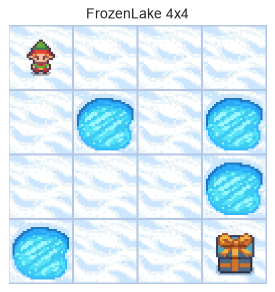

In [3]:
env.reset(seed=0)

fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.imshow(env.render())
ax.set(title="FrozenLake 4x4")
ax.axis("off")
plt.tight_layout()
plt.show()

Note what the transition table shows: choosing `Down` in state 6 leads to state 5, 10 or 7, each with probability 1/3 — and states 5 and 7 are holes. The intended direction is only one of three outcomes, which is what makes the optimal policy counter-intuitive later.

## Step 2: `compute_value_function` — Policy Evaluation

For a fixed policy $\pi$, the value of a state is the expected return from it. The Bellman expectation equation

$$V^{\pi}(s) = \sum_{s'} P(s' \mid s, \pi(s)) \left[ R(s, \pi(s), s') + \gamma V^{\pi}(s') \right]$$

is a linear system, but it is cheaper to apply it repeatedly as an update rule until the values stop moving: each sweep is a contraction, so the iteration converges to the unique fixed point.

In [4]:
def compute_value_function(policy, gamma=1.0, threshold=1e-10, max_sweeps=100_000):
    """Evaluate a policy: iterate the Bellman expectation equation until the values settle."""
    value_table = np.zeros(n_states)

    for sweep in range(max_sweeps):
        updated_value_table = np.copy(value_table)

        for state in range(n_states):
            action = policy[state]
            value_table[state] = sum(
                probability * (reward + gamma * updated_value_table[next_state])
                for probability, next_state, reward, _ in P[state][action]
            )

        if np.max(np.abs(updated_value_table - value_table)) <= threshold:
            return value_table, sweep + 1

    return value_table, max_sweeps


random_policy = np.zeros(n_states, dtype=int)  # "always go Left"
values, sweeps = compute_value_function(random_policy, gamma=1.0)
print(f"Evaluating the all-Left policy took {sweeps} sweeps; V(start) = {values[0]:.4f}")

Evaluating the all-Left policy took 1 sweeps; V(start) = 0.0000


### Policy Improvement

Given the values, the improved policy takes in each state the action with the highest expected return:

$$\pi'(s) = \arg\max_a \sum_{s'} P(s' \mid s, a)\left[R(s, a, s') + \gamma V(s')\right]$$

One detail matters here. When two actions have exactly equal value, a plain `argmax` always picks the lower index, and the policy can flip between two equally good actions forever without the loop ever terminating — this really happens on FrozenLake and is demonstrated below. The remedy is to keep the current action whenever it is among the maximizers, which makes the sequence of policies monotone and the loop finite.

In [5]:
def extract_policy(value_table, gamma=1.0, current_policy=None, tolerance=1e-12):
    """Greedy policy with respect to a value function, keeping the incumbent action on ties."""
    policy = np.zeros(n_states, dtype=int)

    for state in range(n_states):
        q_values = np.array([
            sum(probability * (reward + gamma * value_table[next_state])
                for probability, next_state, reward, _ in P[state][action])
            for action in range(n_actions)
        ])

        if current_policy is not None and q_values[current_policy[state]] >= q_values.max() - tolerance:
            policy[state] = current_policy[state]
        else:
            policy[state] = int(np.argmax(q_values))

    return policy

## Step 3: `policy_iteration`

Evaluate, improve, repeat. The loop stops when an improvement step changes nothing — at that point the policy is greedy with respect to its own value function, which is exactly the Bellman optimality condition.

In [6]:
def policy_iteration(gamma=1.0, n_iterations=1000, verbose=True, tie_safe=True):
    """Alternate evaluation and improvement until the policy stops changing."""
    policy = np.zeros(n_states, dtype=int)
    history = []

    for i in range(n_iterations):
        value_function, sweeps = compute_value_function(policy, gamma)
        new_policy = extract_policy(value_function, gamma,
                                    current_policy=policy if tie_safe else None)

        history.append({
            "iteration": i + 1,
            "evaluation sweeps": sweeps,
            "states changed": int(np.sum(new_policy != policy)),
            "V(start)": value_function[0],
        })

        if np.array_equal(new_policy, policy):
            if verbose:
                print(f"Converged after {i + 1} iterations")
            return policy, value_function, pd.DataFrame(history)

        policy = new_policy

    if verbose:
        print(f"No convergence within {n_iterations} iterations")
    return policy, value_function, pd.DataFrame(history)


optimal_policy, optimal_values, history = policy_iteration(gamma=1.0)
history

Converged after 8 iterations


,iteration,evaluation sweeps,states changed,V(start)
0,1,1,1,0.000000
1,2,43,6,0.000000
2,3,239,4,0.000000
3,4,254,3,0.215909
4,5,363,1,0.297872
5,6,378,2,0.450704
6,7,640,1,0.780488
7,8,808,0,0.823529


In [7]:
grid_shape = env.unwrapped.desc.shape
tiles = env.unwrapped.desc.astype(str)

policy_grid = np.array([ARROWS[a] for a in optimal_policy]).reshape(grid_shape)
policy_grid[tiles == "H"] = "H"
policy_grid[tiles == "G"] = "G"

print("Optimal policy:")
print(pd.DataFrame(policy_grid).to_string(header=False, index=False))
print("\nValue function (probability of eventually reaching the goal, since gamma = 1):")
print(pd.DataFrame(optimal_values.reshape(grid_shape)).round(4).to_string(header=False, index=False))

Optimal policy:
< ^ ^ ^
< H < H
^ v < H
H > v G

Value function (probability of eventually reaching the goal, since gamma = 1):
0.8235 0.8235 0.8235 0.8235
0.8235 0.0000 0.5294 0.0000
0.8235 0.8235 0.7647 0.0000
0.0000 0.8824 0.9412 0.0000


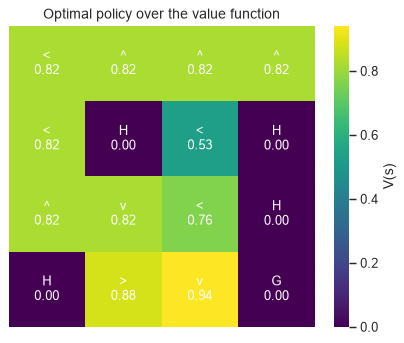

In [8]:
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(optimal_values.reshape(grid_shape), annot=False, cmap="viridis", cbar_kws={"label": "V(s)"}, ax=ax)

for row in range(grid_shape[0]):
    for column in range(grid_shape[1]):
        state = row * grid_shape[1] + column
        label = policy_grid[row, column]
        ax.text(column + 0.5, row + 0.5, f"{label}\n{optimal_values[state]:.2f}",
                ha="center", va="center", color="white", fontsize=11)

ax.set(title="Optimal policy over the value function")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

The policy looks wrong at first glance — in the top-left corner it says *go Left*, away from the goal. It is correct precisely because of the slipperiness: pressing `Left` against the wall means the agent can only slide up or down, never into the hole at state 5. The optimal strategy on this map is largely about choosing actions whose *unintended* outcomes are safe.

## Step 4: `show_render` — Watching the Policy Act

A single episode is played greedily under the optimal policy, and the frames returned by the environment are laid out as a strip. A seed is chosen for which the run reaches the goal, so that the picture shows the intended behaviour rather than a slip into a hole.

Using seed 1


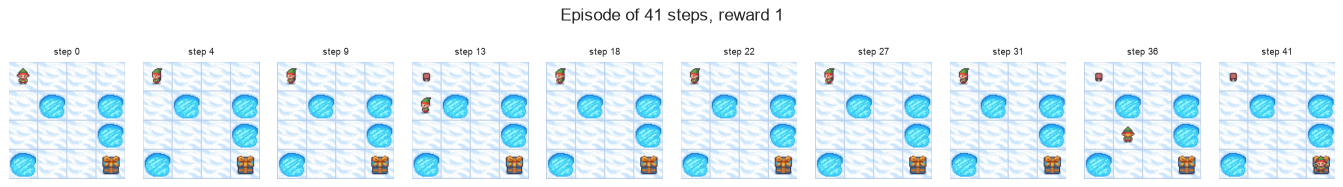

1.0

In [9]:
def run_episode(env, policy, seed, max_steps=200):
    """Play one greedy episode, collecting the rendered frames."""
    state, _ = env.reset(seed=seed)
    frames, total_reward = [env.render()], 0.0

    for _ in range(max_steps):
        state, reward, terminated, truncated, _ = env.step(int(policy[state]))
        frames.append(env.render())
        total_reward += reward
        if terminated or truncated:
            break

    return frames, total_reward


def show_render(env, policy, seed=0, max_frames=10):
    """Render an episode played under `policy` as a strip of frames."""
    frames, reward = run_episode(env, policy, seed)
    indices = np.unique(np.linspace(0, len(frames) - 1, min(max_frames, len(frames))).astype(int))

    fig, axes = plt.subplots(1, len(indices), figsize=(1.6 * len(indices), 2.1))
    for ax, index in zip(np.atleast_1d(axes), indices):
        ax.imshow(frames[index])
        ax.set_title(f"step {index}", fontsize=8)
        ax.axis("off")

    fig.suptitle(f"Episode of {len(frames) - 1} steps, reward {reward:.0f}", y=1.04)
    plt.tight_layout()
    plt.show()
    return reward


# find a seed whose episode ends at the goal, so the strip shows a successful run
successful_seed = next(seed for seed in range(100) if run_episode(env, optimal_policy, seed)[1] > 0)
print(f"Using seed {successful_seed}")
show_render(env, optimal_policy, seed=successful_seed)

## Testing the Policy Against the Environment

With $\gamma = 1$ the value of the start state is exactly the probability of eventually reaching the goal, so $V(\text{start})$ can be checked against the empirical success rate over many episodes. The default environment stops an episode after 100 steps, which the infinite-horizon theory knows nothing about, so both limits are measured.

In [10]:
def success_rate(policy, episodes=5000, max_episode_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    test_env = gym.make("FrozenLake-v1", max_episode_steps=max_episode_steps)
    wins = truncations = 0

    for _ in range(episodes):
        state, _ = test_env.reset(seed=int(rng.integers(1_000_000_000)))
        while True:
            state, reward, terminated, truncated, _ = test_env.step(int(policy[state]))
            if terminated:
                wins += reward > 0
                break
            if truncated:
                truncations += 1
                break

    test_env.close()
    return wins / episodes, truncations / episodes


results = []
for limit in (100, 500, 5000):
    rate, truncated = success_rate(optimal_policy, max_episode_steps=limit)
    results.append({"max_episode_steps": limit, "success rate": rate, "truncated episodes": truncated})

print(f"V(start) predicted by policy iteration: {optimal_values[0]:.4f}\n")
pd.DataFrame(results).round(4)

V(start) predicted by policy iteration: 0.8235



,max_episode_steps,success rate,truncated episodes
0,100,0.7414,0.1068
1,500,0.8318,0.0000
2,5000,0.8318,0.0000


With the default limit the policy appears to succeed 74% of the time, but 11% of episodes are simply cut off mid-way — the policy is deliberately cautious and often takes more than 100 steps. Lifting the limit removes the truncations and the success rate rises to match $V(\text{start}) = 0.8235$ within sampling error. The theory was right; the discrepancy was the time limit.

## Computational Experiments

**The discount factor.** With $\gamma = 1$ future rewards count in full and the agent is willing to take a long, safe route. Lower values make it impatient, and the policy changes accordingly.

In [11]:
rows = []
for gamma in (0.5, 0.7, 0.9, 0.95, 0.99, 1.0):
    policy, values, gamma_history = policy_iteration(gamma=gamma, verbose=False)
    rate, truncated = success_rate(policy, episodes=3000, max_episode_steps=5000)
    rows.append({
        "gamma": gamma,
        "iterations": len(gamma_history),
        "V(start)": values[0],
        "success rate": rate,
        "policy": "".join(ARROWS[a] for a in policy),
    })

pd.DataFrame(rows).round(4)

,gamma,iterations,V(start),success rate,policy
0,0.50,5,0.0004,0.4370,v^>^<<<<^v<<<>v<
1,0.70,5,0.0045,0.4370,v^>^<<<<^v<<<>v<
2,0.90,6,0.0689,0.7853,<^<^<<<<^v<<<>v<
3,0.95,6,0.1805,0.7853,<^<^<<<<^v<<<>v<
4,0.99,7,0.5420,0.8327,<^^^<<<<^v<<<>v<
5,1.00,8,0.8235,0.8327,<^^^<<<<^v<<<>v<


**Tie-breaking.** The same sweep run with a plain `argmax` instead of the incumbent-preserving rule shows where the naive implementation breaks: at some discount factors the policy oscillates between two equally valuable actions and the loop never terminates.

In [12]:
rows = []
for gamma in (0.5, 0.7, 0.9, 1.0):
    for tie_safe in (True, False):
        _, _, naive_history = policy_iteration(gamma=gamma, n_iterations=200, verbose=False, tie_safe=tie_safe)
        rows.append({
            "gamma": gamma,
            "tie-breaking": "keep current action" if tie_safe else "plain argmax",
            "iterations": len(naive_history),
            "converged": len(naive_history) < 200,
        })

pd.DataFrame(rows)

,gamma,tie-breaking,iterations,converged
0,0.5,keep current action,5,True
1,0.5,plain argmax,5,True
2,0.7,keep current action,5,True
3,0.7,plain argmax,200,False
4,0.9,keep current action,6,True
5,0.9,plain argmax,6,True
6,1.0,keep current action,8,True
7,1.0,plain argmax,8,True


**Slippery or not.** Removing the randomness turns the problem into a plain shortest-path search, which makes the cost of the ice explicit.

In [13]:
deterministic_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

P_slippery = P
P = deterministic_env.unwrapped.P          # the solver reads the transition model from P
deterministic_policy, deterministic_values, _ = policy_iteration(gamma=1.0, verbose=False)
P = P_slippery

deterministic_grid = np.array([ARROWS[a] for a in deterministic_policy]).reshape(grid_shape)
deterministic_grid[tiles == "H"] = "H"
deterministic_grid[tiles == "G"] = "G"

print("Optimal policy without slipperiness:")
print(pd.DataFrame(deterministic_grid).to_string(header=False, index=False))
print(f"\nV(start) = {deterministic_values[0]:.4f} against {optimal_values[0]:.4f} on the slippery lake")

frames, reward = run_episode(deterministic_env, deterministic_policy, seed=0)
print(f"A deterministic episode takes {len(frames) - 1} steps and returns reward {reward:.0f}")
deterministic_env.close()

Optimal policy without slipperiness:
v > v <
v H v H
> v v H
H > > G

V(start) = 1.0000 against 0.8235 on the slippery lake
A deterministic episode takes 6 steps and returns reward 1


## Conclusion

**Policy iteration solves the lake exactly.** Starting from the useless all-Left policy it converges in 8 iterations, and the resulting value function is not just a score but a probability: with $\gamma = 1$, $V(\text{start}) = 0.8235$ *is* the chance of reaching the goal. Measured over 5000 episodes without a step limit the policy wins 83% of the time — the model and the environment agree.

**The optimal policy is counter-intuitive, and correctly so.** It pushes into walls and moves away from the goal, because on slippery ice an action is chosen for its unintended outcomes as much as its intended one. Pressing `Left` at the start makes the two possible slips harmless; aiming straight at the goal would make them fatal.

**Two details decide whether the implementation works at all.** A plain `argmax` in the improvement step lets the policy oscillate between equally good actions — at $\gamma = 0.7$ the naive loop never terminates, while keeping the incumbent action converges in 5 iterations. And the default 100-step limit truncates 11% of episodes, which makes a correct policy look 9 points worse than it is.

**The discount factor sets the agent's patience.** At $\gamma = 0.5$–$0.7$ a reward dozens of steps away is worth almost nothing, the agent stops paying for safety, and the success rate collapses to 44%; at $0.9$–$0.95$ it recovers to 79%, and only from $0.99$ upward does it find the fully cautious route worth 83%. Without slipperiness the same code finds a 6-step path with $V = 1$ — the entire difficulty of the task comes from the transition probabilities, not from the map.